# Segmentasi gigi per gigi — SAM 2

Satu tujuan: **tiap gigi jadi satu mask terpisah.** Tidak ada penomoran FDI, tidak ada metrik.

```
foto → region gigi → satu titik per gigi → SAM 2 → mask per gigi
```

Kuncinya di **titik**. SAM 2 sangat andal kalau diberi satu titik di dalam gigi; yang sulit cuma
menemukan titiknya. Karena itu automatic mask generation ditinggalkan — ia menebar grid titik lalu
berharap, dan pada foto intraoral hasilnya kacau.

```bash
pip install -U "transformers[torch]" scikit-image pillow-heif
```

In [23]:
CFG = {
    "img_dir":  "Front Teeth drg Laura",
    "out_dir":  "hasil_segmentasi",
    "max_side": 1024,

    # region gigi
    "col_tiles":   12,     # pita kolom untuk ambang lokal (sudut mulut lebih gelap)
    "local_floor": 0.70,

    # spekular (kilau flash) — piksel ini TIDAK boleh ikut menentukan gigi/gusi
    "spec_L":      82,     # persentil lightness; di atas ini + kroma rendah = kilau
    "spec_chroma": 12.0,   # kroma di bawah ini dianggap kilau
    "fill_frac":   0.035,  # ukuran jendela penambalan warna spekular (x lebar gambar)
    "red_smooth":  0.012,  # penghalusan kanal kemerahan (x lebar gambar)

    # titik per gigi
    "smooth_frac":  0.0021,# sigma penghalusan sebelum hitung tepi (x lebar gambar).
                           # Jendela sempit: terlalu kecil -> noise memecah gigi;
                           # terlalu besar -> garis interproksimal ikut kabur.
    "edge_pct":     78,    # persentil tepi -> dipotong, memisahkan gigi yang berimpit
    "min_cut_frac": 0.22,  # buang serpihan setelah pemotongan
    "dedupe_mult":  0.55,  # radius peleburan titik kembar (x distance transform maks)

    # saring mask
    "min_area_frac": 0.0012,
    "max_area_frac": 0.10,
    "dup_iou":       0.60,
}
import os, json
os.makedirs(CFG["out_dir"], exist_ok=True)
print(CFG)

{'img_dir': 'Front Teeth drg Laura', 'out_dir': 'hasil_segmentasi', 'max_side': 1024, 'col_tiles': 12, 'local_floor': 0.7, 'spec_L': 82, 'spec_chroma': 12.0, 'fill_frac': 0.035, 'red_smooth': 0.012, 'smooth_frac': 0.0021, 'edge_pct': 78, 'min_cut_frac': 0.22, 'dedupe_mult': 0.55, 'min_area_frac': 0.0012, 'max_area_frac': 0.1, 'dup_iou': 0.6}


In [24]:
import glob, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch, warnings
warnings.filterwarnings("ignore")
try:
    from pillow_heif import register_heif_opener; register_heif_opener()
except Exception: pass
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.morphology import binary_opening, binary_closing, disk
from skimage.color import rgb2lab

DEV = torch.device("mps" if torch.backends.mps.is_available()
                   else ("cuda" if torch.cuda.is_available() else "cpu"))

EXTS = ("*.jpg","*.jpeg","*.JPG","*.JPEG","*.png","*.PNG","*.heic","*.HEIC")
paths = sorted(set(sum([glob.glob(os.path.join(CFG["img_dir"], e)) for e in EXTS], [])))
names = [os.path.splitext(os.path.basename(p))[0] for p in paths]

def load_rgb(p):
    im = Image.open(p).convert("RGB")
    if max(im.size) > CFG["max_side"]:
        s = CFG["max_side"]/max(im.size)
        im = im.resize((int(im.width*s), int(im.height*s)), Image.LANCZOS)
    return np.asarray(im, np.uint8)

print(f"{len(paths)} foto | device {DEV}")

18 foto | device mps


## 1. Cari titik — satu per gigi

**Region gigi.** Pembedanya **kemerahan**, bukan kecerahan.

Versi sebelumnya memakai `terang × (1 − jenuh)` dan gagal: pantulan spekular selalu putih, apa
pun warna jaringan di bawahnya. Gusi yang kena kilau flash jadi terang dan tidak jenuh — tak
terbedakan dari gigi, lalu ikut tersambung ke region gigi di sebelahnya.

Tiga langkah perbaikan:

1. **Deteksi kilau** — piksel sangat terang berkroma rendah. Piksel ini tidak membawa informasi
   apa pun tentang jaringan di bawahnya.
2. **Tambal warnanya** dari tetangga non-kilau. Kilau di atas gusi jadi mewarisi kemerahan gusi
   di sekitarnya, kilau di atas gigi tetap pucat.
3. **Ambang pada kanal a\* (kemerahan) Lab** yang sudah dihaluskan. Gigi tidak pernah merah;
   gusi selalu merah. Penghalusan menarik sisa kilau ke arah warna lingkungannya.

**Titik per gigi.** Distance transform region → tiap gigi punya "inti", yaitu titik terjauh dari
tepinya. Tapi gigi yang berimpit menyatu jadi satu gumpalan dengan satu inti saja. Karena itu
region dipotong dulu di **garis tepi interproksimal** — batas enamel antar gigi — sehingga tiap
gigi kembali jadi komponen sendiri. Satu titik per komponen.

In [25]:
def lab_parts(rgb):
    """-> L*, a* (kemerahan), kroma."""
    lab = rgb2lab(rgb.astype(np.float32)/255.)
    L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
    return L, a, np.hypot(a, b)

def specular_mask(L, chroma):
    """Kilau flash: sangat terang DAN kroma rendah."""
    return (L >= np.percentile(L, CFG["spec_L"])) & (chroma <= CFG["spec_chroma"])

def fill_specular(a, spec, W):
    """
    Ganti kemerahan piksel kilau dengan rata-rata tetangga NON-kilau.

    Inti perbaikannya: piksel spekular tidak membawa informasi warna jaringan di bawahnya,
    jadi ia tidak boleh ikut memilih. Setelah ditambal, kilau di atas gusi mewarisi
    kemerahan gusi dan tidak lagi menyamar sebagai gigi.
    """
    if not spec.any(): return a
    k = max(3, int(CFG["fill_frac"]*W) | 1)
    valid = (~spec).astype(np.float32)
    num = ndi.uniform_filter(np.where(spec, 0.0, a).astype(np.float32), size=k)
    den = ndi.uniform_filter(valid, size=k)
    out = a.copy()
    out[spec] = (num/np.maximum(den, 1e-6))[spec]
    return out

def toothness(rgb):
    """Skor 'seperti gigi' = KURANG MERAH. Tahan kilau flash."""
    W = rgb.shape[1]
    L, a, chroma = lab_parts(rgb)
    spec = specular_mask(L, chroma)
    a_fix = fill_specular(a, spec, W)
    a_sm = ndi.gaussian_filter(a_fix, CFG["red_smooth"]*W)
    t = -a_sm                                  # makin tidak merah, makin mirip gigi
    t = t - t.min()
    t = t/max(t.max(), 1e-6)
    return t * (0.35 + 0.65*np.clip(L/100.0, 0, 1))   # rongga gelap tetap ditekan

def tooth_region(rgb):
    W = rgb.shape[1]
    t = toothness(rgb)
    g = float(threshold_otsu(t))
    reg = t > g
    edges = np.linspace(0, W, CFG["col_tiles"]+1).astype(int)
    for x0, x1 in zip(edges[:-1], edges[1:]):
        tile = t[:, x0:x1]
        if tile.size < 50 or tile.max() < g: continue
        try: loc = float(threshold_otsu(tile))
        except Exception: continue
        reg[:, x0:x1] = tile > max(min(loc, g), CFG["local_floor"]*g)
    r = max(1, int(0.006*W))
    reg = binary_closing(binary_opening(reg, disk(r)), disk(r))
    lab_, n = ndi.label(reg)
    if n:
        sz = ndi.sum(reg, lab_, range(1, n+1))
        reg = np.isin(lab_, 1 + np.nonzero(sz >= 0.02*sz.max())[0])
    return reg

def find_points(rgb):
    """-> daftar (x, y), satu titik per gigi."""
    reg = tooth_region(rgb)
    if not reg.any(): return [], reg

    # potong di garis tepi -> gigi yang berimpit terpisah kembali.
    # Dihaluskan dulu: tanpa itu noise sensor bikin gradien berbintik dan satu gigi
    # pecah jadi beberapa komponen. Jendela sigma-nya sempit (lihat CFG).
    t = ndi.gaussian_filter(toothness(rgb), CFG["smooth_frac"]*rgb.shape[1])
    gy, gx = np.gradient(t)
    edge = np.hypot(gx, gy)
    # "<=" bukan "<": di area rata gradiennya persis 0, jadi persentilnya juga 0
    # dan perbandingan ketat membuang SEMUA piksel.
    thr = float(np.percentile(edge[reg], CFG["edge_pct"]))
    cut = binary_opening(reg & (edge <= thr), disk(1))
    if not cut.any(): cut = reg.copy()

    lab_, n = ndi.label(cut)
    if n == 0: return [], reg
    sz = ndi.sum(cut, lab_, range(1, n+1))
    med = float(np.median(sz[sz > 0]))
    pts = []
    for i in range(1, n+1):
        if sz[i-1] < max(CFG["min_cut_frac"]*med, 25): continue
        d = ndi.distance_transform_edt(lab_ == i)
        y, x = np.unravel_index(int(np.argmax(d)), d.shape)
        pts.append((int(x), int(y)))

    dt = ndi.distance_transform_edt(reg)
    rad = max(4, int(CFG["dedupe_mult"]*float(dt.max())))
    keep = []
    for p in pts:
        if all((p[0]-q[0])**2 + (p[1]-q[1])**2 > rad*rad for q in keep): keep.append(p)
    return keep, reg

def occlusal_y(reg):
    """Garis pemisah rahang atas/bawah: lembah profil baris region gigi."""
    row = reg.sum(1).astype(float)
    if row.max() == 0: return reg.shape[0]//2
    k = max(3, len(row)//40)
    sm = np.convolve(row, np.ones(k)/k, mode="same")
    lo, hi = int(.30*len(sm)), int(.80*len(sm))
    return lo + int(np.argmin(sm[lo:hi])) if hi > lo else len(sm)//2

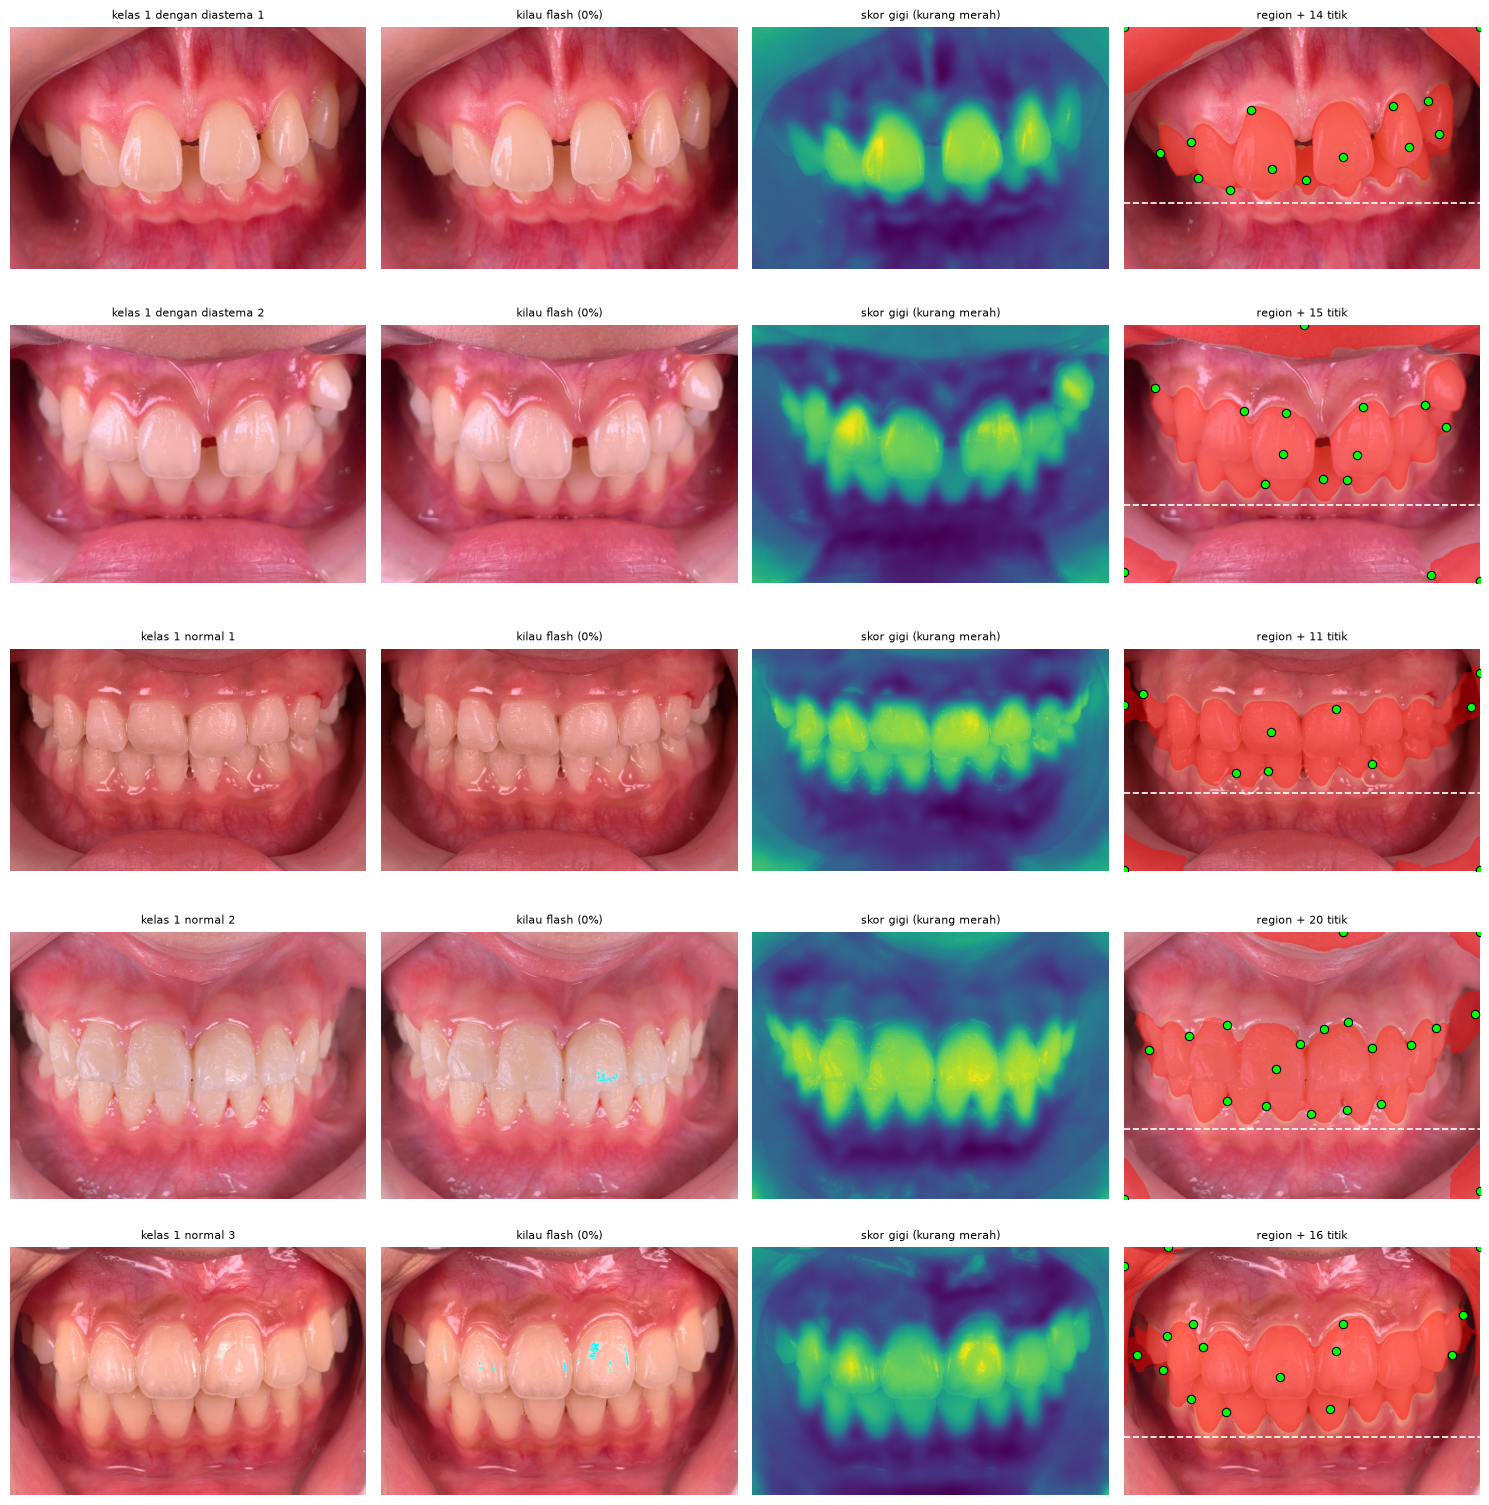

Panel 2 = piksel yang diabaikan saat menentukan gigi/gusi.
Panel 3 = skor kemerahan; gusi harus gelap, gigi terang.
Panel 4 = region akhir + garis oklusal (putus-putus) + titik.


In [26]:
# Cek DULU sebelum menyentuh SAM. Empat panel supaya kelihatan di mana salahnya
# kalau gusi masih ikut terbawa.
n_show = min(5, len(paths))
fig, ax = plt.subplots(n_show, 4, figsize=(15, 3.1*n_show))
ax = np.atleast_2d(ax)
for i in range(n_show):
    rgb = load_rgb(paths[i])
    L, a_raw, chroma = lab_parts(rgb)
    spec = specular_mask(L, chroma)
    pts, reg = find_points(rgb)
    y_occ = occlusal_y(reg)

    ax[i,0].imshow(rgb); ax[i,0].set_title(names[i][:28], fontsize=8)
    ax[i,1].imshow(rgb); ax[i,1].imshow(np.ma.masked_where(~spec, spec), cmap="cool", alpha=.9)
    ax[i,1].set_title(f"kilau flash ({100*spec.mean():.0f}%)", fontsize=8)
    ax[i,2].imshow(toothness(rgb), cmap="viridis")
    ax[i,2].set_title("skor gigi (kurang merah)", fontsize=8)
    ax[i,3].imshow(rgb); ax[i,3].imshow(np.ma.masked_where(~reg, reg), cmap="autumn", alpha=.45)
    ax[i,3].axhline(y_occ, color="w", lw=1.2, ls="--")
    if pts:
        x, y = zip(*pts); ax[i,3].plot(x, y, "o", ms=6, mfc="lime", mec="k", mew=.8)
    ax[i,3].set_title(f"region + {len(pts)} titik", fontsize=8)
    for a_ in ax[i]: a_.axis("off")
plt.tight_layout(); plt.show()
print("Panel 2 = piksel yang diabaikan saat menentukan gigi/gusi.")
print("Panel 3 = skor kemerahan; gusi harus gelap, gigi terang.")
print("Panel 4 = region akhir + garis oklusal (putus-putus) + titik.")

## 2. SAM 2 — titik jadi mask

Tiap titik dikirim sebagai prompt positif. `multimask_output=True` memberi 3 kandidat per titik
(biasanya: sebagian gigi / satu gigi utuh / gigi + tetangga) — dipilih yang luasnya wajar dan
paling menempel di region gigi.

In [27]:
from transformers import Sam2Model, Sam2Processor
model = Sam2Model.from_pretrained("facebook/sam2.1-hiera-large").to(DEV).eval()
processor = Sam2Processor.from_pretrained("facebook/sam2.1-hiera-large")
print("SAM 2 siap")

def _to_masks(out, inp):
    """post_process_masks beda tanda tangan antar versi transformers."""
    pm, osz = out.pred_masks.cpu(), inp["original_sizes"].cpu()
    try:
        return processor.post_process_masks(pm, osz)[0]
    except TypeError:
        return processor.post_process_masks(pm, osz, inp["reshaped_input_sizes"].cpu())[0]

@torch.no_grad()
def sam_masks(rgb, pts):
    if not pts: return []
    inp = processor(images=Image.fromarray(rgb),
                    input_points=[[[list(p)] for p in pts]],
                    input_labels=[[[1] for _ in pts]],
                    return_tensors="pt").to(DEV)
    out = model(**inp, multimask_output=True)
    m = _to_masks(out, inp)                 # (n_titik, n_kandidat, H, W)
    s = out.iou_scores.cpu().numpy()[0]
    return [[(np.asarray(m[i, c], bool), float(s[i, c])) for c in range(m.shape[1])]
            for i in range(m.shape[0])]

def pilih(cands, reg, A):
    """Kandidat yang paling menyerupai SATU gigi."""
    best, bs = None, -9e9
    for mask, sc in cands:
        a = mask.sum()
        if a == 0: continue
        if not (CFG["min_area_frac"] <= a/A <= CFG["max_area_frac"]): continue
        nempel = np.logical_and(mask, reg).sum()/a
        v = 2.0*nempel + sc
        if v > bs: bs, best = v, mask
    return best

def bersihkan(masks, A):
    masks = sorted(masks, key=lambda m: -m.sum())
    keep = []
    for m in masks:
        if any(np.logical_and(m, k).sum()/min(m.sum(), k.sum()) > CFG["dup_iou"] for k in keep):
            continue
        keep.append(m)
    return sorted(keep, key=lambda m: np.nonzero(m)[1].mean())   # kiri -> kanan

def segmentasi(rgb, pts=None):
    if pts is None: pts, reg = find_points(rgb)
    else:           reg = tooth_region(rgb)
    A = rgb.shape[0]*rgb.shape[1]
    hasil = [pilih(c, reg, A) for c in sam_masks(rgb, pts)]
    masks = bersihkan([m for m in hasil if m is not None], A)
    y_occ = occlusal_y(reg)
    arch = ["atas" if np.nonzero(m)[0].mean() < y_occ else "bawah" for m in masks]
    return masks, pts, arch, y_occ

[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

SAM 2 siap


In [28]:
HASIL = {}
t0 = time.time()
for p, n in zip(paths, names):
    rgb = load_rgb(p)
    masks, pts, arch, y_occ = segmentasi(rgb)
    HASIL[n] = {"rgb": rgb, "masks": masks, "pts": pts, "arch": arch, "y_occ": y_occ}
    na, nb = arch.count("atas"), arch.count("bawah")
    print(f"  {n[:40]:40s} {len(pts):2d} titik -> {len(masks):2d} gigi  "
          f"(atas {na:2d} | bawah {nb:2d})")
print(f"\nselesai dalam {(time.time()-t0)/60:.1f} menit")

  kelas 1 dengan diastema 1                14 titik ->  9 gigi  (atas  9 | bawah  0)
  kelas 1 dengan diastema 2                15 titik -> 10 gigi  (atas  7 | bawah  3)
  kelas 1 normal 1                         11 titik ->  9 gigi  (atas  7 | bawah  2)
  kelas 1 normal 2                         20 titik -> 18 gigi  (atas 16 | bawah  2)
  kelas 1 normal 3                         16 titik -> 14 gigi  (atas 14 | bawah  0)
  kelas 1 with crossbite and crowding 1    14 titik -> 14 gigi  (atas 12 | bawah  2)
  kelas 1 with crowding lower anterior 1   11 titik -> 10 gigi  (atas  0 | bawah 10)
  kelas 1 with crowding lower anterior 2    8 titik ->  5 gigi  (atas  5 | bawah  0)
  kelas 1 with crowding, midline shifting, 14 titik ->  9 gigi  (atas  8 | bawah  1)
  kelas 1 with crowding, midline shifting,  7 titik ->  7 gigi  (atas  7 | bawah  0)
  kelas 1 with deep bite and protrusion 1   8 titik ->  6 gigi  (atas  6 | bawah  0)
  kelas 1 with deep bite and protrusion 2   8 titik ->  8 gigi  (

## 3. Hasil — outline tiap gigi, hijau atas / merah bawah

Pembagian rahang memakai **garis oklusal**: lembah pada profil baris region gigi, yaitu tempat
kedua lengkung bertemu. Tiap mask ditempatkan berdasarkan posisi vertikal pusatnya.

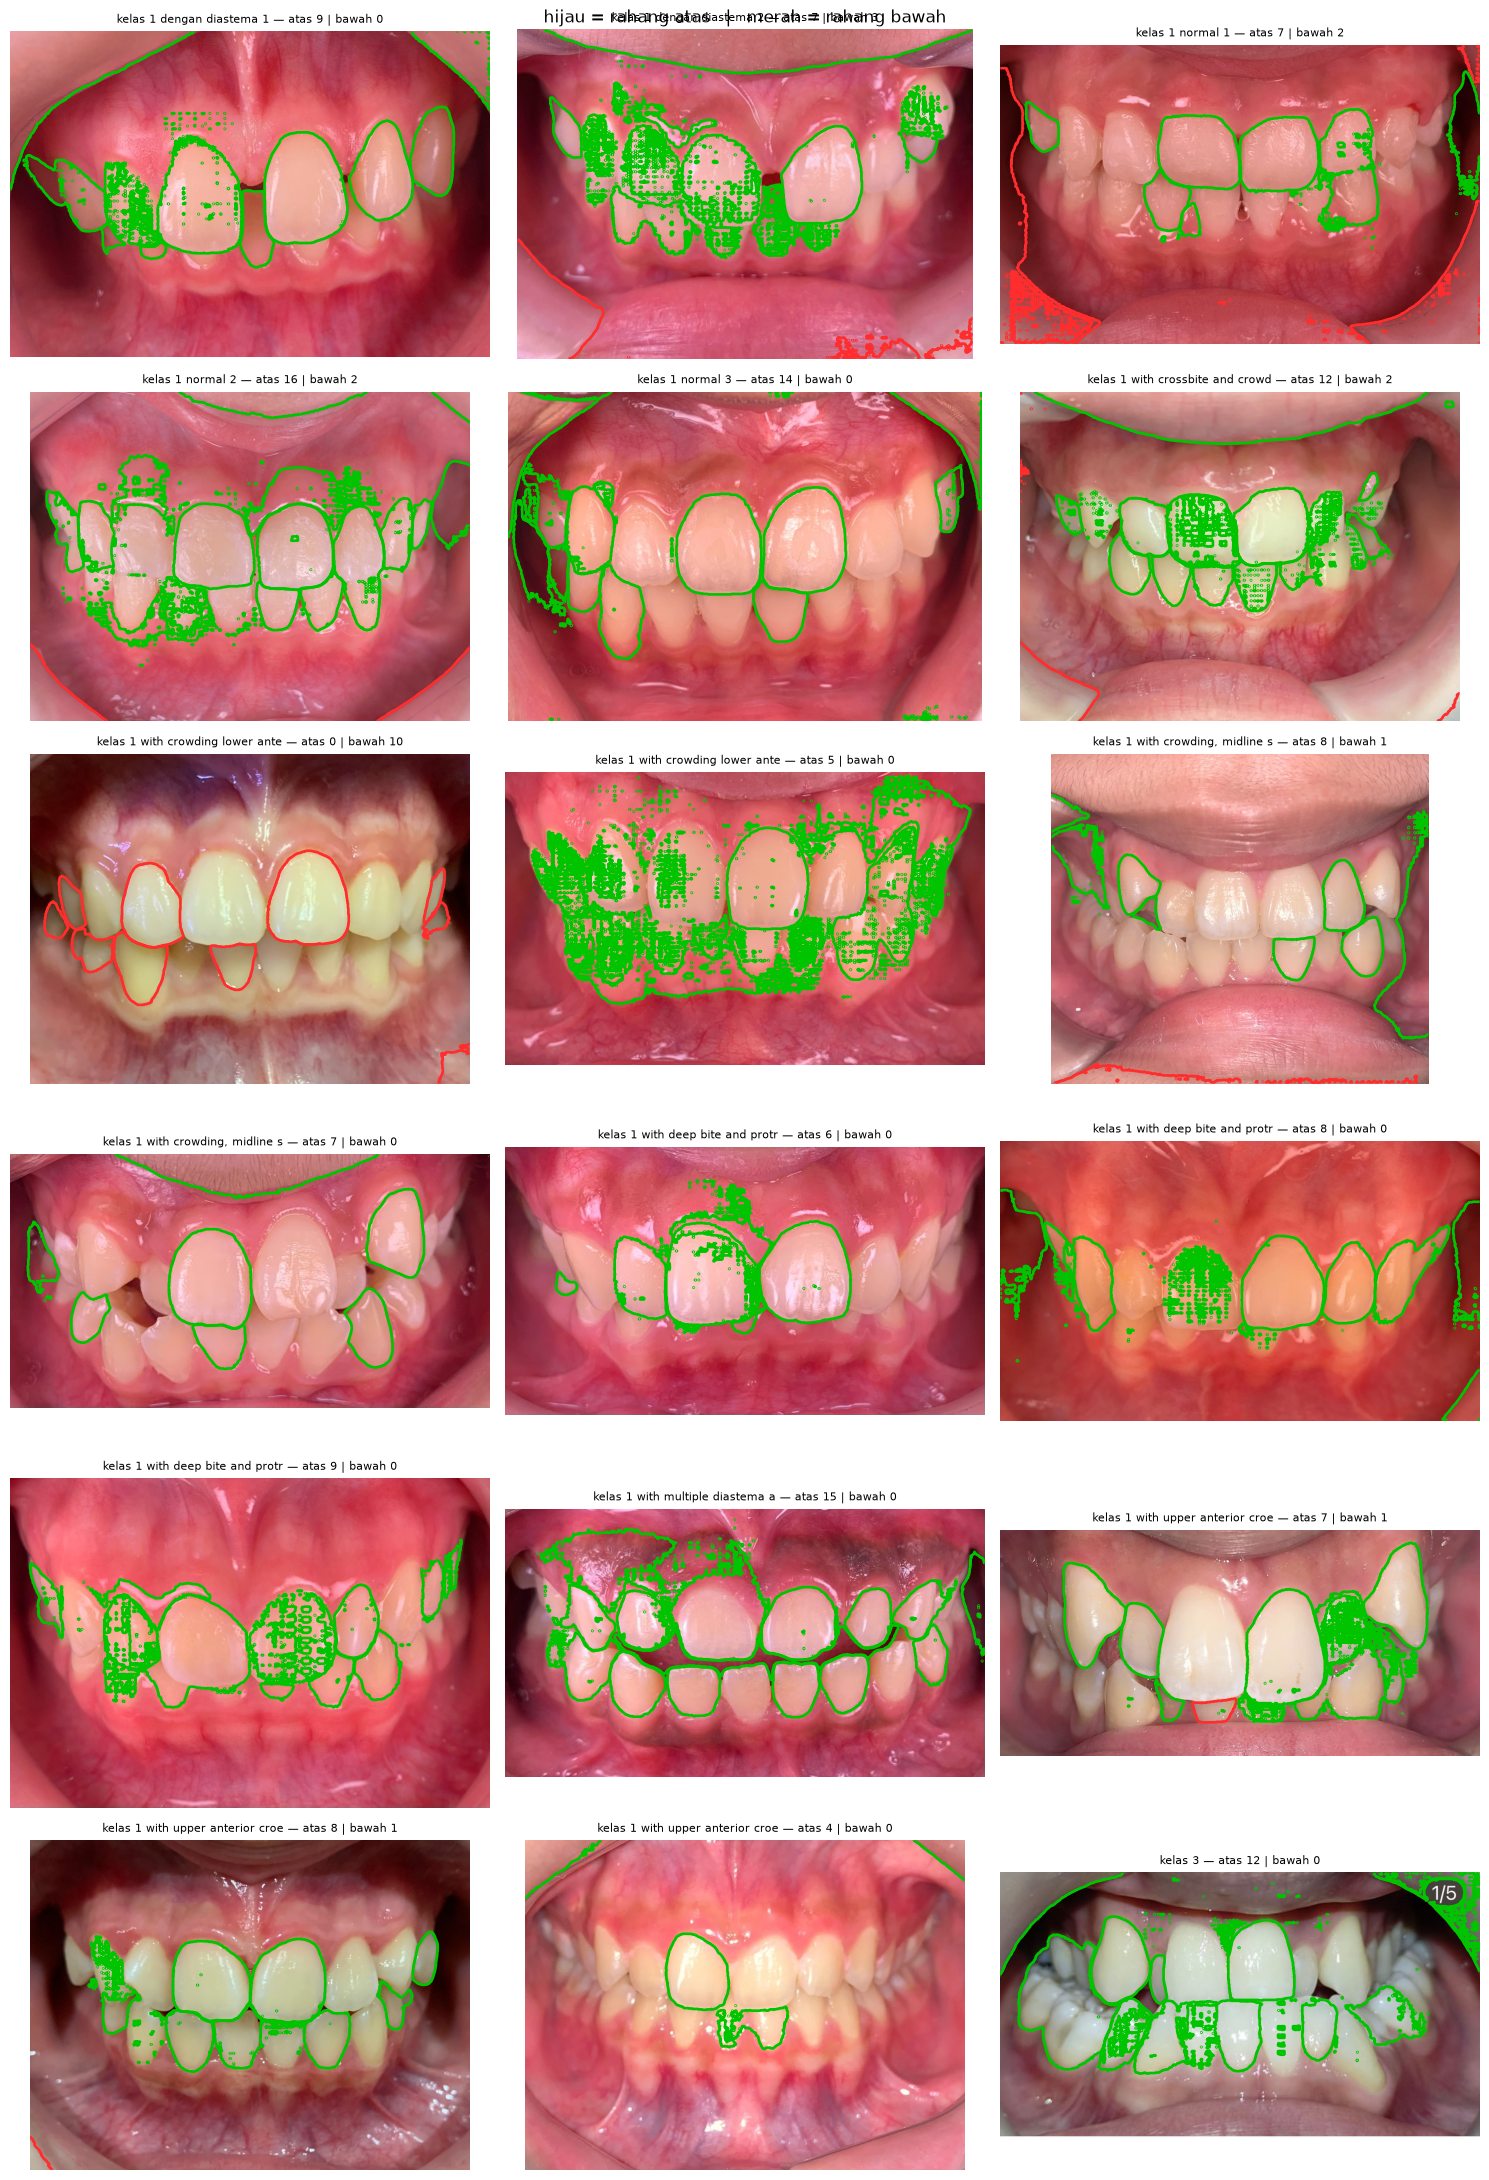

In [29]:
HIJAU, MERAH = "#00c400", "#ff2d2d"

def tampil(n, ax=None, garis=False):
    d = HASIL[n]
    if ax is None: _, ax = plt.subplots(figsize=(7,5))
    ax.imshow(d["rgb"]); ax.axis("off")
    for m, a_ in zip(d["masks"], d["arch"]):
        ax.contour(m, levels=[0.5], colors=[HIJAU if a_ == "atas" else MERAH], linewidths=1.9)
    if garis: ax.axhline(d["y_occ"], color="w", lw=1, ls="--", alpha=.7)
    na, nb = d["arch"].count("atas"), d["arch"].count("bawah")
    ax.set_title(f"{n[:32]} — atas {na} | bawah {nb}", fontsize=8)

ns = list(HASIL); nc = 3; nr = int(np.ceil(len(ns)/nc))
fig, axes = plt.subplots(nr, nc, figsize=(15, 3.7*nr))
for a in np.ravel(axes): a.axis("off")
for k, n in enumerate(ns): tampil(n, np.ravel(axes)[k])
plt.suptitle("hijau = rahang atas   |   merah = rahang bawah", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Perbaiki yang meleset

Kalau ada gigi yang terlewat atau titiknya salah, tulis titik yang benar di sini dan jalankan
ulang khusus foto itu. Jalankan sel bawah untuk melihat foto bergaris koordinat.

In [30]:
def grid(n, step=50):
    d = HASIL[n]; rgb = d["rgb"]; H, W = rgb.shape[:2]
    fig, ax = plt.subplots(figsize=(11, 11*H/W))
    ax.imshow(rgb)
    for x in range(0, W, step): ax.axvline(x, color="w", lw=.4, alpha=.6)
    for y in range(0, H, step): ax.axhline(y, color="w", lw=.4, alpha=.6)
    for m in d["masks"]: ax.contour(m, levels=[0.5], colors="cyan", linewidths=.8)
    if d["pts"]:
        x, y = zip(*d["pts"]); ax.plot(x, y, "o", ms=6, mfc="lime", mec="k")
    ax.set_xticks(range(0, W, step*2)); ax.set_yticks(range(0, H, step*2))
    ax.tick_params(labelsize=7); ax.set_title(n[:50], fontsize=9)
    plt.tight_layout(); plt.show()

# grid(names[0])       # <- buka komentarnya untuk membaca koordinat

In [31]:
# Setel smooth_frac / edge_pct pada FOTO ASLI. Jendela smooth_frac sempit —
# terlalu kecil noise memecah gigi, terlalu besar garis interproksimal ikut kabur.
def sweep(n, param="smooth_frac", nilai=(0.0012, 0.0021, 0.0030, 0.0042)):
    rgb = HASIL[n]["rgb"]; asli = CFG[param]
    fig, ax = plt.subplots(1, len(nilai), figsize=(3.2*len(nilai), 3.6))
    for a, v in zip(np.ravel(ax), nilai):
        CFG[param] = v
        pts, _ = find_points(rgb)
        a.imshow(rgb); a.axis("off")
        if pts:
            x, y = zip(*pts); a.plot(x, y, "o", ms=5, mfc="lime", mec="k", mew=.7)
        a.set_title(f"{param}={v}\n{len(pts)} titik", fontsize=8)
    CFG[param] = asli
    plt.suptitle(f"{n[:46]} — pilih yang satu titik per gigi", fontsize=10)
    plt.tight_layout(); plt.show()

# sweep(names[0])                      # sigma penghalusan
# sweep(names[0], "edge_pct", (68, 74, 78, 84))

In [32]:
TITIK_MANUAL = {
    # "nama file tanpa ekstensi": [(x1,y1), (x2,y2), ...],
}

for n, pts in TITIK_MANUAL.items():
    if n not in HASIL: print("tidak ada:", n); continue
    masks, _, arch, y_occ = segmentasi(HASIL[n]["rgb"], pts=[tuple(p) for p in pts])
    HASIL[n].update({"masks": masks, "pts": [tuple(p) for p in pts],
                     "arch": arch, "y_occ": y_occ})
    print(f"  {n[:40]:40s} -> {len(masks)} gigi "
          f"(atas {arch.count('atas')} | bawah {arch.count('bawah')})")
    tampil(n); plt.show()

## 5. Simpan

In [33]:
import re
np.savez_compressed(os.path.join(CFG["out_dir"], "masks.npz"),
    **{f"{n}__{i}": HASIL[n]["masks"][i] for n in HASIL for i in range(len(HASIL[n]["masks"]))})
with open(os.path.join(CFG["out_dir"], "hasil.json"), "w") as f:
    json.dump({n: {"titik": [list(map(int, p)) for p in HASIL[n]["pts"]],
                   "rahang": HASIL[n]["arch"],
                   "y_oklusal": int(HASIL[n]["y_occ"])} for n in HASIL}, f, indent=1)

# simpan overlay PNG per foto
for n in HASIL:
    fig, ax = plt.subplots(figsize=(8, 8*HASIL[n]["rgb"].shape[0]/HASIL[n]["rgb"].shape[1]))
    tampil(n, ax)
    fig.savefig(os.path.join(CFG["out_dir"],
                f"outline_{re.sub(r'[^A-Za-z0-9]+','_',n)[:48]}.png"),
                dpi=120, bbox_inches="tight")
    plt.close(fig)

tot_a = sum(h["arch"].count("atas") for h in HASIL.values())
tot_b = sum(h["arch"].count("bawah") for h in HASIL.values())
for n in HASIL:
    d = HASIL[n]
    print(f"  {n[:42]:42s} {len(d['masks']):2d} gigi "
          f"(atas {d['arch'].count('atas'):2d} | bawah {d['arch'].count('bawah'):2d})")
print(f"\ntotal {tot_a+tot_b} gigi — atas {tot_a}, bawah {tot_b}")
print("->", CFG["out_dir"], "(masks.npz, hasil.json, outline_*.png)")

  kelas 1 dengan diastema 1                   9 gigi (atas  9 | bawah  0)
  kelas 1 dengan diastema 2                  10 gigi (atas  7 | bawah  3)
  kelas 1 normal 1                            9 gigi (atas  7 | bawah  2)
  kelas 1 normal 2                           18 gigi (atas 16 | bawah  2)
  kelas 1 normal 3                           14 gigi (atas 14 | bawah  0)
  kelas 1 with crossbite and crowding 1      14 gigi (atas 12 | bawah  2)
  kelas 1 with crowding lower anterior 1     10 gigi (atas  0 | bawah 10)
  kelas 1 with crowding lower anterior 2      5 gigi (atas  5 | bawah  0)
  kelas 1 with crowding, midline shifting, c  9 gigi (atas  8 | bawah  1)
  kelas 1 with crowding, midline shifting, c  7 gigi (atas  7 | bawah  0)
  kelas 1 with deep bite and protrusion 1     6 gigi (atas  6 | bawah  0)
  kelas 1 with deep bite and protrusion 2     8 gigi (atas  8 | bawah  0)
  kelas 1 with deep bite and protrusion 3     9 gigi (atas  9 | bawah  0)
  kelas 1 with multiple diastema and o

## 6. Validasi terhadap data beranotasi (Roboflow Universe)

Semua uji sejauh ini memakai gigi sintetis — itu hanya membuktikan **implementasinya benar**,
bukan bahwa pipeline ini bekerja pada gigi sungguhan. Bagian ini memberi angka yang selama ini
belum ada: **IoU dan Dice terhadap mask hasil anotasi manusia**.

Datanya dari Roboflow Universe, semuanya lisensi CC BY 4.0:

| Dataset | Gambar | Catatan |
|---|---|---|
| [Teeth Instance Segmentation](https://universe.roboflow.com/yolo-sxtmz/teeth-gzkv1) | 1.746 | Terbesar. Kelasnya kondisi (healthy/mild/medium/severe), bukan identitas gigi — untuk kita cukup, kelas diabaikan |
| [Dentist Dataset Segmentation](https://universe.roboflow.com/siddiqui/dentist-dataset-segmentation) | 649 | Instance per gigi |
| [Dental Image Segmentation](https://universe.roboflow.com/dental-image-segmentation/dental-image-segmentation-lauua) | 350 | Semantic, bukan instance |
| [TOOTH SEGMENTATION](https://universe.roboflow.com/teeth-segmentation-18aan/tooth-segmentation-w10hy) | 84 | Kecil, tapi ada model terlatihnya |

**Baca hasilnya dengan hati-hati.** Foto di dataset ini belum tentu intraoral retraksi seperti
punyamu — sebagian foto senyum biasa, sudut dan pencahayaannya berbeda. Konvensi anotasinya juga
mungkin lain (batas gigi/gusi, gigi posterior disertakan atau tidak). Jadi IoU rendah bisa berarti
pipeline kita salah, **atau** berarti domainnya memang berbeda. Panel visual di akhir bagian ini
yang menentukan mana di antara keduanya.

Nilai keduanya:
1. **Validasi** — angka nyata untuk ditulis di skripsi, menggantikan "terlihat bagus".
2. **Data latih** — kalau nanti mau otomatis penuh dengan YOLOv8-seg, ini titik awalnya.

```bash
pip install roboflow
```

API key gratis: daftar di roboflow.com → Settings → Roboflow API. Tanpa key, sel di bawah
dilewati dengan rapi dan tidak meruntuhkan Run All.

In [34]:
RF = {
    "api_key":   os.environ.get("ROBOFLOW_API_KEY", ""),   # atau tempel langsung di sini
    "workspace": "yolo-sxtmz",
    "project":   "teeth-gzkv1",
    "version":   8,
    "split":     "test",     # train | valid | test
    "n_eval":    25,         # berapa gambar dievaluasi (None = semua)
    "iou_match": 0.50,       # ambang IoU untuk dianggap cocok
    "dir":       "roboflow_data",
}

DS = None
if not RF["api_key"]:
    print("ROBOFLOW_API_KEY belum diset — bagian validasi dilewati.")
    print("Set lewat:  export ROBOFLOW_API_KEY=xxxx   (atau isi RF['api_key'] di atas)")
else:
    try:
        from roboflow import Roboflow
        rf = Roboflow(api_key=RF["api_key"])
        proj = rf.workspace(RF["workspace"]).project(RF["project"])
        DS = proj.version(RF["version"]).download("yolov8", location=RF["dir"])
        print("terunduh ->", DS.location)
    except Exception as e:
        print("gagal mengunduh:", type(e).__name__, str(e)[:200])
        print("Cek API key, atau unduh manual dari halaman dataset (format YOLOv8).")

ROBOFLOW_API_KEY belum diset — bagian validasi dilewati.
Set lewat:  export ROBOFLOW_API_KEY=xxxx   (atau isi RF['api_key'] di atas)


In [35]:
from PIL import ImageDraw

def poly_to_mask(poly_norm, W, H):
    """Poligon ternormalisasi (YOLOv8-seg) -> mask boolean."""
    pts = [(x*W, y*H) for x, y in zip(poly_norm[0::2], poly_norm[1::2])]
    if len(pts) < 3: return None
    im = Image.new("L", (W, H), 0)
    ImageDraw.Draw(im).polygon(pts, fill=1)
    return np.asarray(im, bool)

def baca_anotasi(img_path, lbl_path, W, H):
    """-> daftar mask ground-truth. Kelas diabaikan; kita cuma perlu 'ini gigi'."""
    if not os.path.exists(lbl_path): return []
    out = []
    for line in open(lbl_path):
        v = line.split()
        if len(v) < 7: continue
        m = poly_to_mask([float(x) for x in v[1:]], W, H)
        if m is not None and m.sum() > 20: out.append(m)
    return out

def iou(a, b):
    inter = np.logical_and(a, b).sum()
    return 0.0 if inter == 0 else float(inter/np.logical_or(a, b).sum())

def dice(a, b):
    inter = np.logical_and(a, b).sum()
    return 0.0 if inter == 0 else float(2*inter/(a.sum() + b.sum()))

def cocokkan(pred, gt, thr):
    """Pencocokan greedy berdasarkan IoU tertinggi. -> (pasangan, n_pred, n_gt)."""
    skor = [(iou(p, g), i, j) for i, p in enumerate(pred) for j, g in enumerate(gt)]
    skor.sort(reverse=True)
    dipakai_p, dipakai_g, pasangan = set(), set(), []
    for v, i, j in skor:
        if v < thr or i in dipakai_p or j in dipakai_g: continue
        dipakai_p.add(i); dipakai_g.add(j); pasangan.append((i, j, v))
    return pasangan, len(pred), len(gt)

In [36]:
import pandas as pd

if DS is None:
    print("Lewati — dataset belum terunduh.")
else:
    root = os.path.join(DS.location, RF["split"])
    imgs = sorted(glob.glob(os.path.join(root, "images", "*.*")))
    if RF["n_eval"]: imgs = imgs[:RF["n_eval"]]
    print(f"{len(imgs)} gambar dievaluasi dari split '{RF['split']}'\n")

    baris = []
    EVAL = {}
    for ip in imgs:
        stem = os.path.splitext(os.path.basename(ip))[0]
        lp = os.path.join(root, "labels", stem + ".txt")
        rgb = load_rgb(ip)
        H, W = rgb.shape[:2]
        gt = baca_anotasi(ip, lp, W, H)
        if not gt: continue
        masks, pts, arch, y_occ = segmentasi(rgb)
        pas, npred, ngt = cocokkan(masks, gt, RF["iou_match"])
        EVAL[stem] = {"rgb": rgb, "pred": masks, "gt": gt, "pas": pas, "arch": arch}
        baris.append({
            "gambar": stem[:28],
            "gt": ngt, "pred": npred, "cocok": len(pas),
            "presisi": round(len(pas)/max(npred, 1), 3),
            "recall":  round(len(pas)/max(ngt, 1), 3),
            "IoU":     round(float(np.mean([v for _, _, v in pas])), 3) if pas else 0.0,
            "Dice":    round(float(np.mean([dice(masks[i], gt[j]) for i, j, _ in pas])), 3) if pas else 0.0,
        })

    V = pd.DataFrame(baris)
    if len(V):
        print(V.to_string(index=False))
        print("\n===== RINGKASAN =====")
        print(f"  gambar          : {len(V)}")
        print(f"  gigi (anotasi)  : {V.gt.sum()}   terdeteksi: {V.pred.sum()}   cocok: {V.cocok.sum()}")
        print(f"  presisi         : {V.cocok.sum()/max(V.pred.sum(),1):.3f}")
        print(f"  recall          : {V.cocok.sum()/max(V.gt.sum(),1):.3f}")
        print(f"  IoU rata-rata   : {V.IoU[V.IoU>0].mean():.3f}")
        print(f"  Dice rata-rata  : {V.Dice[V.Dice>0].mean():.3f}")
        V.to_csv(os.path.join(CFG["out_dir"], "validasi_roboflow.csv"), index=False)
        print("\nPatokan kasar: IoU >0.7 baik, 0.5-0.7 cukup, <0.5 ada yang salah")
        print("(atau domainnya memang berbeda — lihat panel visual di bawah).")
    else:
        print("Tidak ada gambar dgn anotasi terbaca. Cek RF['split'].")

Lewati — dataset belum terunduh.


In [37]:
# Bandingkan berdampingan: anotasi manusia vs pipeline kita.
# Ini yang menentukan apakah IoU rendah berarti kita salah, atau domainnya beda.
if 'EVAL' in dir() and EVAL:
    pilih_n = sorted(EVAL, key=lambda k: -len(EVAL[k]["gt"]))[:4]
    fig, ax = plt.subplots(len(pilih_n), 2, figsize=(11, 4.2*len(pilih_n)))
    ax = np.atleast_2d(ax)
    for r, k in enumerate(pilih_n):
        d = EVAL[k]
        ax[r,0].imshow(d["rgb"])
        for m in d["gt"]: ax[r,0].contour(m, levels=[0.5], colors="#ffd000", linewidths=1.5)
        ax[r,0].set_title(f"anotasi manusia — {len(d['gt'])} gigi", fontsize=9)
        ax[r,1].imshow(d["rgb"])
        for m, a_ in zip(d["pred"], d["arch"]):
            ax[r,1].contour(m, levels=[0.5],
                            colors=[HIJAU if a_ == "atas" else MERAH], linewidths=1.6)
        ax[r,1].set_title(f"pipeline kita — {len(d['pred'])} gigi, "
                          f"{len(d['pas'])} cocok", fontsize=9)
        for a_ in ax[r]: a_.axis("off")
    plt.suptitle("kuning = ground truth   |   hijau/merah = prediksi (atas/bawah)", fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print("Belum ada hasil evaluasi.")

Belum ada hasil evaluasi.


### Menafsirkan hasilnya

| Pola | Artinya |
|---|---|
| Recall rendah, presisi tinggi | Gigi terlewat — longgarkan `edge_pct` / `min_cut_frac` |
| Presisi rendah, recall tinggi | Ada yang bukan gigi ikut terdeteksi — perketat region (`local_floor`) |
| IoU sedang (0.5–0.7) tapi bentuk mirip | Beda konvensi batas gigi/gusi, bukan kesalahan kita |
| IoU rendah + bentuk jelas beda | Pipeline memang salah di domain itu |
| Bagus di dataset, buruk di foto drg. Laura | Domain shift — setel ulang pada fotomu sendiri, jangan pada dataset |

Yang terakhir itu penting. Dataset ini alat **verifikasi**, bukan target optimasi. Parameter tetap
harus disetel pada foto yang akan kamu pakai.

## Kalau masih meleset

Setel satu per satu, mulai dari yang paling berdampak:

| Gejala | Setel |
|---|---|
| **Gusi mengilap masih ikut** | turunkan `spec_L` ke 75, naikkan `spec_chroma` ke 18 |
| **Kilau tidak tertambal rapi** | naikkan `fill_frac` ke 0.05 |
| **Batas gigi/gusi berombak** | naikkan `red_smooth` ke 0.02 |
| Region gigi bocor ke gusi | naikkan `local_floor` ke 0.8 |
| Gigi pojok hilang dari region | naikkan `col_tiles` ke 16 |
| Dua gigi jadi satu titik | naikkan `edge_pct` ke 84–88 |
| Satu gigi dapat dua titik | naikkan `dedupe_mult` ke 0.7 |
| Mask menjalar ke gusi | turunkan `max_area_frac` ke 0.07 |

Untuk gigi yang tumpang tindih berat, garis interproksimalnya memang nyaris hilang dan tidak ada
setelan yang menolong — pakai `TITIK_MANUAL`. Untuk 18 foto itu jalan tercepat, bukan kegagalan.